# **CHAPTER 13**
##  **Loading and Preprocessing Data with TensorFlow**

## **The Data API**

In [2]:
import tensorflow as tf
import keras

In [5]:
X = tf.range(10)
dataset = tf.data.Dataset.from_tensor_slices(X)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

from_tensor_slices() function takes a tensor and creates a tf.data.Dataset
whose elements are all the slices of X (along the first dimension), so this dataset con‐
tains 10 items: tensors 0, 1, 2, …, 9.

In [6]:
for item in dataset:
    print(item)


tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)
tf.Tensor(9, shape=(), dtype=int32)


## **Chaining Transformations**

In [7]:
dataset = dataset.repeat(3).batch(7)
for item in dataset:
    print(item)

tf.Tensor([0 1 2 3 4 5 6], shape=(7,), dtype=int32)
tf.Tensor([7 8 9 0 1 2 3], shape=(7,), dtype=int32)
tf.Tensor([4 5 6 7 8 9 0], shape=(7,), dtype=int32)
tf.Tensor([1 2 3 4 5 6 7], shape=(7,), dtype=int32)
tf.Tensor([8 9], shape=(2,), dtype=int32)


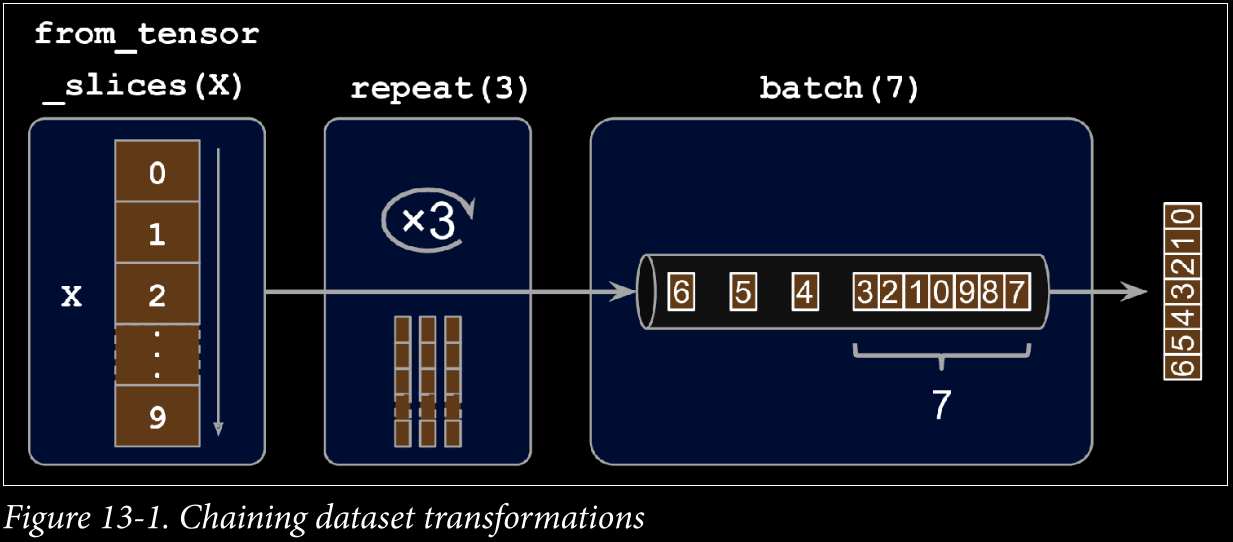

## map() applies a function to every item.

In [11]:
dataset = dataset.map(lambda x: x * 2)
for item in dataset:
    print(item)


tf.Tensor([  0  32  64  96 128 160 192], shape=(7,), dtype=int32)
tf.Tensor([224 256 288   0  32  64  96], shape=(7,), dtype=int32)
tf.Tensor([128 160 192 224 256 288   0], shape=(7,), dtype=int32)
tf.Tensor([ 32  64  96 128 160 192 224], shape=(7,), dtype=int32)
tf.Tensor([256 288], shape=(2,), dtype=int32)


In [12]:
# dataset = dataset.map(preprocess_image) # preprocess_image will be a function

## filter()

Removes unwanted data.

In [ ]:
dataset = dataset.filter(lambda x: x < 10)

##  shuffle()

Why shuffle?

Because neural networks learn better when data is random.

In [ ]:
dataset.shuffle(buffer_size=5)

## take()

Take only a few samples.

In [ ]:
dataset.take(3)

In [ ]:
dataset = (
    dataset
    .shuffle(10000)
    .map(preprocess)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

    Dataset
    |
    ↓
    Shuffle
    (randomize examples)

    |
    ↓
    Map
    (preprocess)

    |
    ↓
    Batch
    (make groups of 32)

    |
    ↓
    Prefetch
    (load next batch while GPU trains)

# interleave()

## Loading Large CSV Files

In [26]:
from pathlib import Path
import tensorflow as tf

DATASET_PATH = Path("/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data")

TRAIN_PATH = tf.data.Dataset.list_files(str(DATASET_PATH / "easy_ham/*"))
TEST_PATH = tf.data.Dataset.list_files(str(DATASET_PATH / "spam/*"))

In [29]:
i = 0
for emails in TRAIN_PATH:
    print(emails)
    if i == 5:
        break
    i += 1

tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/02085.fff553bbd7afbe7514d53ee72c3a0f96', shape=(), dtype=string)
tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/01278.a6b5dc8309ecd924c2ee872d35899de7', shape=(), dtype=string)
tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/01671.572d5d58699f0b03e959bbdc6ee14e83', shape=(), dtype=string)
tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/00187.f2e1e617b73fa1c5137d78383372886f', shape=(), dtype=string)
tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/01261.eafbf152124bcd764327d9fda1e8c86f', shape=(), dtype=string)
tf.Tensor(b'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Data/spam_data/easy_ham/00303.72eec73b937da55ad1c649c0092f75ad', shape=(), dtype=string)


In [30]:
dataset = TRAIN_PATH.interleave(
    lambda filepath: tf.data.TextLineDataset(filepath)
)

    Reading:

    file1 completely
    then file2
    then file3

    creates patterns.

    Instead:

    file1 → line 1
    file2 → line 1
    file3 → line 1
    file4 → line 1

    file1 → line 2
    file2 → line 2
    ...

    This is interleaving.

## **Pipeline**


    Files
    |
    |
    Dataset.list_files()

    |
    ↓

    Read images

    |
    ↓

    map()
    resize images
    normalize pixels

    |
    ↓

    shuffle()

    |
    ↓

    batch(32)

    |
    ↓

    GPU Training

In [51]:
def preprocess(line):
    defs = [0.0] * n_inputs + [0.0]

    fields = tf.io.decode_csv(line, record_defaults=defs)

    x = tf.stack(fields[:-1])  
    y = tf.stack(fields[-1:]) 

    x_normalized = (x - X_mean) / X_std

    return x_normalized, y

In [ ]:
from pathlib import Path
import pandas as pd
import tensorflow as tf

DATASET_PATH = Path(
    r"/home/noneo/Codes/ML/MachineLearning/Datasets/advertising1D.csv"
)

df = pd.read_csv(DATASET_PATH)

feature_df = df[["expenditure"]].dropna()

X_mean = tf.constant(feature_df.mean().values, dtype=tf.float32)  # Shape: (1,)
X_std = tf.constant(feature_df.std().values, dtype=tf.float32)  # Shape: (1,)

n_inputs = 1

sample_csv_line = tf.constant("230.1,22.1")  # Example line: expenditure=230.1, sales=22.1

x_norm, y_val = preprocess(sample_csv_line)

print("Normalized X:", x_norm.numpy())
print("Target Y:    ", y_val.numpy())

Normalized X: [0.31445333]
Target Y:     [22.1]


**Use interleave only when each file contains multiple records you want mixed together (CSV rows, TFRecord entries). If one file = one record (like a single image), skip interleave — just list_files → map → shuffle → batch.**

In [ ]:
def csv_reader_dataset(filepaths, repeat=1, n_readers=5,
                       n_read_threads=None, shuffle_buffer_size=10000,
                       n_parse_threads=5, batch_size=32):
    dataset = tf.data.Dataset.list_files(filepaths)
    dataset = dataset.interleave( lambda filepath: 
        tf.data.TextLineDataset(filepath).skip(1),
        cycle_length=n_readers, num_parallel_calls=n_read_threads)
    dataset = dataset.map(preprocess, num_parallel_calls=n_parse_threads)
    dataset = dataset.shuffle(shuffle_buffer_size).repeat(repeat)
    return dataset.batch(batch_size).prefetch(1)

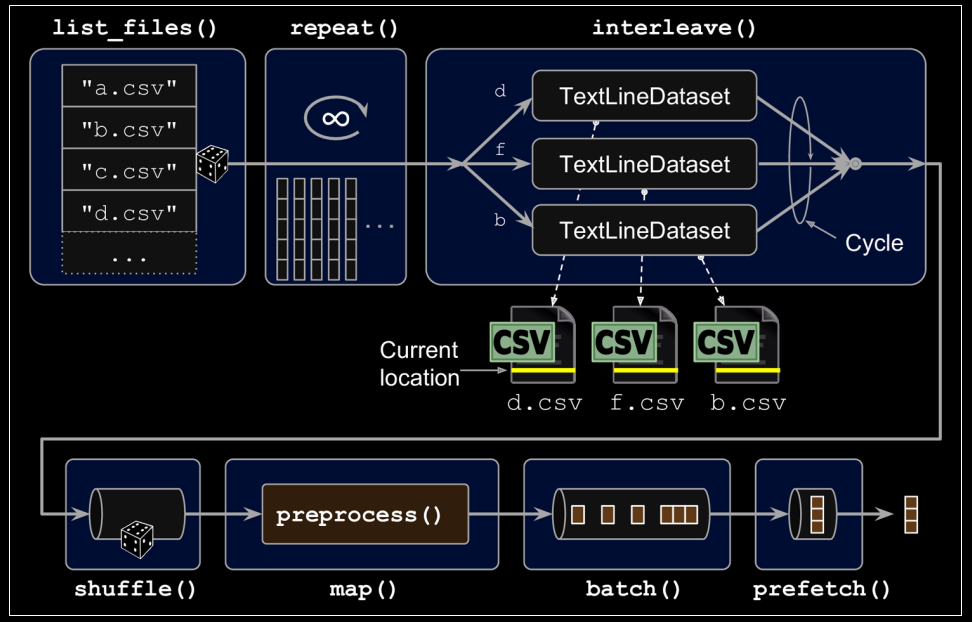

train_set = csv_reader_dataset(train_filepaths)
valid_set = csv_reader_dataset(valid_filepaths)
test_set = csv_reader_dataset(test_filepaths)

In [52]:
from pathlib import Path
import tensorflow as tf

BASE_PATH = Path("~/Codes/DeepLearning/DL Datasets/cats_and_dogs_filtered/cats_and_dogs_filtered").expanduser()

TRAIN_PATH = BASE_PATH / "train"
VALID_PATH = BASE_PATH / "validation"


def process_image(file_path):
    raw_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(raw_img, channels=3)
    img = tf.image.resize(img, [150, 150]) / 255.0

    # Assign label based on path (1 for dogs, 0 for cats)
    label = tf.where(
        tf.strings.regex_full_match(file_path, ".*dogs.*"),
        tf.constant(1, dtype=tf.int32),
        tf.constant(0, dtype=tf.int32),
    )
    return img, label


def create_interleaved_dataset(data_dir, batch_size=32):

    cats_files = tf.data.Dataset.list_files(str(data_dir / "cats" / "*.jpg"))
    dogs_files = tf.data.Dataset.list_files(str(data_dir / "dogs" / "*.jpg"))

    file_ds = tf.data.Dataset.from_tensor_slices([cats_files, dogs_files])

    dataset = file_ds.interleave(
        lambda ds: ds,
        cycle_length=2,  # Read concurrently from both 'cats' and 'dogs'
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    
    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# Create train and validation pipelines
TRAIN_SET = create_interleaved_dataset(TRAIN_PATH)
VALID_SET = create_interleaved_dataset(VALID_PATH)

In [54]:
# 1. Loaded Pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3), include_top=False, weights="imagenet"
)

base_model.trainable = False  # Freeze base layers to preserve feature weights

/tmp/ipykernel_328526/975315385.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [58]:
from keras import layers 
model = keras.models.Sequential(
    [
        layers.Input(shape=(150, 150, 3)),
        
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),

        base_model,

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),  # Binary output: Cat (0) vs Dog (1)
    ]
)

In [66]:
EPOCHS = 15
BATCH_SIZE = 32
NUM_TRAIN_IMAGES = 2000

steps_per_epoch = NUM_TRAIN_IMAGES // BATCH_SIZE
total_steps = EPOCHS * steps_per_epoch

In [67]:
class OneCycleLR(tf.keras.callbacks.Callback):
    """1Cycle Learning Rate Policy Callback with Cosine Annealing."""

    def __init__(
        self,
        total_steps,
        max_lr,
        pct_start=0.3,
        div_factor=25.0,
        final_div_factor=10000.0,
    ):
        super().__init__()
        self.total_steps = total_steps
        self.max_lr = max_lr
        self.pct_start = pct_start
        self.initial_lr = max_lr / div_factor
        self.final_lr = self.initial_lr / final_div_factor

        self.step_size_up = float(pct_start * total_steps)
        self.step_size_down = float(total_steps - self.step_size_up)
        self.current_step = 0

    def on_train_batch_begin(self, batch, logs=None):
        self.current_step += 1

        if self.current_step <= self.step_size_up:
            # Phase 1: Cosine ramp-up to max_lr
            pct = self.current_step / self.step_size_up
            lr = self.initial_lr + 0.5 * (self.max_lr - self.initial_lr) * (
                1 - np.cos(np.pi * pct)
            )
        else:
            # Phase 2: Cosine decay to final_lr
            pct = (self.current_step - self.step_size_up) / self.step_size_down
            lr = self.final_lr + 0.5 * (self.max_lr - self.final_lr) * (
                1 + np.cos(np.pi * pct)
            )

        # Assign updated learning rate to optimizer
        self.model.optimizer.learning_rate.assign(lr)

In [68]:
one_cycle = OneCycleLR(
    total_steps=total_steps,
    max_lr=1e-3,
    pct_start=0.3,
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/CATDOGCLASSIFIER/best.keras",
    monitor="val_loss",
    save_best_only=True,
)

root_logdir = os.path.join(os.curdir, "my_logs/CATANDDOGCLASSIFIER_LOG/")
run_logdir = os.path.join(
    root_logdir, time.strftime("run_%Y_%m_%d-%H_%M_%S")
)
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)


In [69]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [70]:
history = model.fit(
    TRAIN_SET,
    validation_data=VALID_SET,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[one_cycle, early_stop, checkpoint_cb, tensorboard_cb],
)

Epoch 1/15


W0000 00:00:1785404911.538477  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.587115  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.591199  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.605393  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.609637  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.614144  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.622949  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.627207  332903 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404911.631558  332903 gp

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6755 - loss: 0.6566

W0000 00:00:1785404924.327972  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.330979  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.333885  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.336913  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.339908  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.342866  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.345968  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.348981  332898 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404924.351969  332898 gp

62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.7999 - loss: 0.4376 - val_accuracy: 0.9850 - val_loss: 0.1215
Epoch 2/15


W0000 00:00:1785404926.298564  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.301769  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.304951  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.308512  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.312181  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.315515  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.319008  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.322463  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404926.326063  332902 gp

 1/62 ━━━━━━━━━━━━━━━━━━━━ 1:31 1s/step - accuracy: 0.9375 - loss: 0.1742

W0000 00:00:1785404927.732630  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404927.735876  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404927.739194  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404927.742542  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785404927.751539  332902 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9375 - loss: 0.1742 - val_accuracy: 0.9860 - val_loss: 0.1162
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.9980 - loss: 0.0401 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0157
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 1.0000 - loss: 6.6947e-04 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 9/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - va

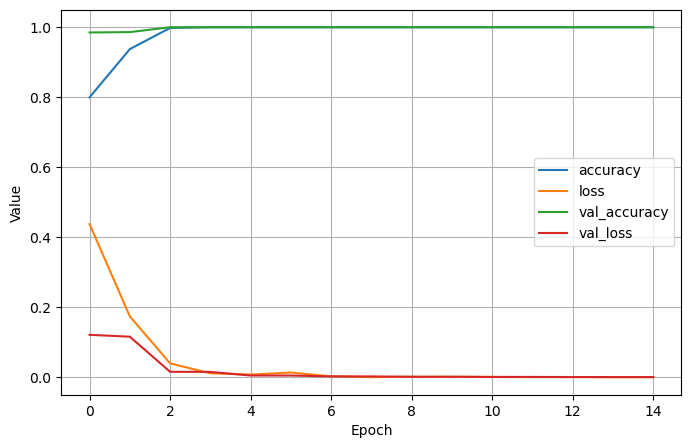

In [72]:
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()

In [75]:
%load_ext tensorboard
%tensorboard --logdir my_logs/CATANDDOGCLASSIFIER_LOG/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 467913), started 0:00:12 ago. (Use '!kill 467913' to kill it.)

In [76]:
!kill 467913

In [82]:

def load_and_preprocess_single_image(image_path):
    raw_img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(raw_img, channels=3)
    img = tf.image.resize(img, [150, 150]) / 255.0  # Rescale to [0, 1]

    img_batch = tf.expand_dims(img, axis=0)

    return img_batch


image_path2 = (r"/home/noneo/Pictures/Screenshots/Screenshot from 2026-07-30 15-13-43.png")
image_path = (r"/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/TestModel.jpeg")
image_tensor2 = load_and_preprocess_single_image(image_path2)
image_tensor = load_and_preprocess_single_image(image_path)

prob2 = model.predict(image_tensor2)[0][0]
prob = model.predict(image_tensor)[0][0]

label = "Dog" if prob >= 0.5 else "Cat"
confidence = prob if prob >= 0.5 else (1 - prob)

label2 = "Dog" if prob2 >= 0.5 else "Cat"
confidence2 = prob2 if prob2 >= 0.5 else (1 - prob2)

print(f"Result: {label} ({confidence * 100:.2f}% confidence)")
print(f"Result: {label2} ({confidence2 * 100:.2f}% confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Result: Dog (99.99% confidence)
Result: Dog (98.87% confidence)


# **The TFRecord Format**

Think of a .tfrecord file as a big bag of "chunks" of binary data, one after another. Each chunk (record) has:

a length (how many bytes it is)
a checksum (to check nothing got corrupted)
the actual data
another checksum



In [2]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd

with tf.io.TFRecordWriter("Data/my_data.tfrecord") as f:
    f.write(b"This is the first record")
    f.write(b"And this is the second record")

2026-08-01 01:27:42.298639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 01:27:42.384791: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 01:27:42.409336: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


    CSV
    │
    ├── pandas.read_csv()
    │
    ├── tf.train.Example
    │
    ├── TFRecordWriter
    ▼
    train.tfrecord
    │
    ├── TFRecordDataset
    ├── parse_single_example()
    ├── map()
    ├── batch()
    ▼
    model.fit(dataset)

    CSV File
        │
        ▼
    Read with Pandas
        │
        ▼
    Convert each row → tf.train.Example
        │
        ▼
    Save as .tfrecord
        │
        ▼
    Read with TFRecordDataset
        │
        ▼
    Parse back into tensors

In [3]:
df = pd.read_csv(r"/home/noneo/Codes/ML/MachineLearning/Datasets/outliers.csv")
df

,x1,x2,y
0,11.0,0.140452,11.0
1,19.0,0.473867,15.0
2,31.0,1.713352,20.0
3,16.0,0.888953,13.0
4,36.0,0.118194,23.0
...,...,...,...
9995,30.0,1.705223,20.0
9996,28.0,2.444101,19.0
9997,37.0,1.089873,24.0
9998,36.0,0.776210,23.0


In [6]:
import os
import tensorflow as tf

os.makedirs('TFRecord_Data', exist_ok=True)

with tf.io.TFRecordWriter('TFRecord_Data/data.tfrecord') as w:
    
    for _, row in df.iterrows():
        
        example = tf.train.Example(
            
            features=tf.train.Features(
                
                feature={
                    'x1': tf.train.Feature(int64_list=tf.train.Int64List(value=[int(row['x1'])])),
                    'x2': tf.train.Feature(float_list=tf.train.FloatList(value=[float(row['x2'])])),
                    'y':  tf.train.Feature(int64_list=tf.train.Int64List(value=[int(row['y'])]))
                }
            )
        )
        w.write(example.SerializeToString())


In [ ]:
import tensorflow as tf

feature_description = {
    'x1': tf.io.FixedLenFeature([], tf.int64),
    'x2': tf.io.FixedLenFeature([], tf.float32),
    'y':  tf.io.FixedLenFeature([], tf.int64),
}

def parse_tfrecord_fn(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)

dataset = (
    tf.data.TFRecordDataset("/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/TFRecord_Data/data.tfrecord")
    .map(parse_tfrecord_fn)
)

# Test iteration again
for sample in dataset.take(3):
    print(sample)

{'x1': <tf.Tensor: shape=(), dtype=int64, numpy=11>, 'x2': <tf.Tensor: shape=(), dtype=float32, numpy=0.14045206>, 'y': <tf.Tensor: shape=(), dtype=int64, numpy=11>}
{'x1': <tf.Tensor: shape=(), dtype=int64, numpy=19>, 'x2': <tf.Tensor: shape=(), dtype=float32, numpy=0.47386718>, 'y': <tf.Tensor: shape=(), dtype=int64, numpy=15>}
{'x1': <tf.Tensor: shape=(), dtype=int64, numpy=31>, 'x2': <tf.Tensor: shape=(), dtype=float32, numpy=1.7133518>, 'y': <tf.Tensor: shape=(), dtype=int64, numpy=20>}


In [13]:
dataset

<_MapDataset element_spec={'x1': TensorSpec(shape=(), dtype=tf.int64, name=None), 'x2': TensorSpec(shape=(), dtype=tf.float32, name=None), 'y': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [ ]:
EPOCH = 100
BATCH_SIZE = 32

def prepare(example):

    x = tf.stack([
        tf.cast(example["x1"], tf.float32),
        example["x2"]
    ])

    y = example["y"]

    return x, y


dataset = (
    dataset
    .map(prepare, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# model.fit(dataset)

## **For Image**

    dataset/
    │
    ├── cats/
    │   ├── cat1.jpg
    │   ├── cat2.jpg
    │
    └── dogs/
        ├── dog1.jpg
        ├── dog2.jpg

### **Convert Images → TFRecord**

In [17]:
from pathlib import Path

dataset_path = Path("dataset")

classes = {
    "cats": 0,
    "dogs": 1
}

with tf.io.TFRecordWriter("images.tfrecord") as writer:

    for class_name, label in classes.items():

        for image_path in (dataset_path / class_name).glob("*.jpg"):

            # Read image as raw bytes
            image = image_path.read_bytes()

            example = tf.train.Example(
                features=tf.train.Features(
                    feature={
                        "image": tf.train.Feature(
                            bytes_list=tf.train.BytesList(value=[image])
                        ),
                        "label": tf.train.Feature(
                            int64_list=tf.train.Int64List(value=[label])
                        )
                    }
                )
            )

            writer.write(example.SerializeToString())

print("TFRecord Created!")

TFRecord Created!


In [ ]:
feature_description = {
    "image": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.int64),
}

### **Parse Each Example**

In [18]:
IMG_SIZE = (224, 224)

def parse_example(example):

    example = tf.io.parse_single_example(
        example,
        feature_description
    )

    image = tf.image.decode_jpeg(
        example["image"],
        channels=3
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    label = example["label"]

    return image, label

### **Load the TFRecord**

In [ ]:
dataset = (
    tf.data.TFRecordDataset("images.tfrecord")
    .map(parse_example,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
for images, labels in dataset.take(1):
    print(images.shape)
    print(labels.shape)
    
# model.fit(dataset, epochs=10)

# **Protocol Buffers**

A protobuf is just a template/schema for structuring data efficiently in binary form — Google invented it. Instead of writing your own custom format, you describe your data shape once:

    message Person {
    string name = 1;
    int32 id = 2;
    repeated string email = 3;
    }


In [ ]:
example = tf.train.Example(
                features=tf.train.Features(
                    feature={
                        "image": tf.train.Feature(
                            bytes_list=tf.train.BytesList(value=[image])
                        ),
                        "label": tf.train.Feature(
                            int64_list=tf.train.Int64List(value=[label])
                        )
                    }
                )
            )

Reading/parsing

In [20]:
feature_description = {
    'x1': tf.io.FixedLenFeature([], tf.int64),
    'x2': tf.io.FixedLenFeature([], tf.float32),
    'y':  tf.io.FixedLenFeature([], tf.int64),
}

## **Encoding Categorical Features Using Embeddings**

OOV (Out-Of-Vocabulary) means a word/category that the model has never seen during training.


Now during inference, the model receives:

I love birds

birds was not in the training vocabulary.

The model does not know its ID.

So we map unknown words into an OOV bucket.

In [23]:
import tensorflow as tf

words = ['I', "Love", "dogs", "Cat", "pit"]
embedding_dim = len(words)  # Dimension is 5
vocab_size = 1000
num_oov_buckets = 10  # Out-Of-Vocabulary

embed_init = tf.random.uniform([vocab_size + num_oov_buckets, embedding_dim])

In [24]:
embedding_matrix = tf.Variable(embed_init)

In [25]:
embedding_matrix

<tf.Variable 'Variable:0' shape=(1010, 5) dtype=float32, numpy=
array([[0.26495683, 0.9390712 , 0.8003155 , 0.2897792 , 0.6716324 ],
       [0.61436677, 0.04054546, 0.13873553, 0.2156322 , 0.4241078 ],
       [0.79919446, 0.01511776, 0.821236  , 0.4860463 , 0.48240864],
       ...,
       [0.00955021, 0.85277474, 0.78501284, 0.13561952, 0.0879395 ],
       [0.6468662 , 0.03332818, 0.03614795, 0.0788281 , 0.6756942 ],
       [0.06977654, 0.33944786, 0.7777461 , 0.27341604, 0.09770322]],
      dtype=float32)>

In [ ]:
unique_categories = tf.constant(["NEAR BAY", "<INLAND>", "INLAND", "ISLAND"])
indices = tf.constant([0, 1, 2, 3], dtype=tf.int64)

initializer = tf.lookup.KeyValueTensorInitializer(unique_categories, indices)
num_oov_buckets = 1  
table = tf.lookup.StaticVocabularyTable(initializer, num_oov_buckets)

embedding_dim = 4
vocab_size = len(unique_categories) + num_oov_buckets
embedding_matrix = tf.random.uniform([vocab_size, embedding_dim])

categories = tf.constant(["NEAR BAY", "DESERT", "INLAND", "INLAND"])

cat_indices = table.lookup(categories)
embeddings = tf.nn.embedding_lookup(embedding_matrix, cat_indices)

print("Indices:", cat_indices.numpy())
print("Embeddings Shape:", embeddings.shape)
print("Embeddings:\n", embeddings.numpy())

Indices: [0 4 2 2]
Embeddings Shape: (4, 4)
Embeddings:
 [[0.42568588 0.6829523  0.88483965 0.91657424]
 [0.13977504 0.7656177  0.10403633 0.993731  ]
 [0.61970365 0.8703959  0.47797358 0.8405298 ]
 [0.61970365 0.8703959  0.47797358 0.8405298 ]]


In [31]:
embedding = keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)
embedding(cat_indices)

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[ 0.0203866 ,  0.04041832, -0.02044305, -0.01837514],
       [-0.01475067, -0.04254815,  0.00502205,  0.00930659],
       [-0.04511292,  0.00136878, -0.04879749,  0.00424691],
       [-0.04511292,  0.00136878, -0.04879749,  0.00424691]],
      dtype=float32)>

In [ ]:

# Sample Vocabulary
vocab = ["NEAR BAY", "INLAND", "NEAR OCEAN", "ISLAND", "DESERT"]

# 1. Inputs
regular_inputs = keras.layers.Input(shape=[8], name="regular_inputs")
categories = keras.layers.Input(shape=[1], dtype=tf.string, name="categories")

# 2. String Lookup Layer
lookup_layer = keras.layers.StringLookup(vocabulary=vocab, num_oov_indices=1)
cat_indices = lookup_layer(categories)

# 3. Embedding Layer
embedding_layer = keras.layers.Embedding(input_dim=len(vocab) + 1, output_dim=2)
cat_embed = embedding_layer(cat_indices)

# 4. Flattening Layer
cat_embed_flat = keras.layers.Flatten()(cat_embed)

# 5. Concatenation Layer
encoded_inputs = keras.layers.concatenate([regular_inputs, cat_embed_flat])

# 6. Model Definition
model = keras.Model(inputs=[regular_inputs, categories], outputs=encoded_inputs)

In [ ]:
normalization = keras.layers.Normalization()
discretization = keras.layers.Discretization([...])
pipeline = keras.layers.PreprocessingStage([normalization, discretization])

# pipeline.adapt(data_sample)

Step 1: Input Layer Setup

    Python
        regular_inputs = keras.layers.Input(shape=[8], name="regular_inputs")
        categories = keras.layers.Input(shape=[1], dtype=tf.string, name="categories")

What it does: Defines the entry points for your data into the model.

Notebook Execution & Shapes:
    Imagine a single data sample passing through:regular_inputs: [2.5, 30.0, 5.2, 1.1, 800.0, 250.0, 37.8, -122.2] $\rightarrow$ Shape: (1, 8)categories: [["NEAR BAY"]] $\rightarrow$ Shape: (1, 1) with dtype=tf.stringStep 

2: Converting Text to Numerical Indices
    
    Python
        lookup_layer = keras.layers.StringLookup(vocabulary=vocab, num_oov_indices=1)
        cat_indices = lookup_layer(categories)

What it does: Maps raw text strings into discrete integer IDs based on the vocabulary index table.

Notebook Execution & Shapes:

- The StringLookup internal dictionary looks like this:
    -Index 0 $\rightarrow$ Empty padding (reserved)
    - Index 1 $\rightarrow$ "NEAR BAY"Index 2 $\rightarrow$ "INLAND"
    -Index 3 $\rightarrow$ "NEAR OCEAN"Index 4 $\rightarrow$ "ISLAND"
    -Index 5 $\rightarrow$ "DESERT"
    -Index 6 $\rightarrow$ [OOV] (Out-Of-Vocabulary for unknown strings)
- Passing [["NEAR BAY"]]:
    - cat_indices = lookup_layer([["NEAR BAY"]]) $\rightarrow$ Output: [[1]]
    - Shape: (1, 1) with dtype=tf.int64Step 

3: Mapping Integer Indices to Dense Vectors

    Python
        embedding_layer = keras.layers.Embedding(input_dim=6, output_dim=2)
        cat_embed = embedding_layer(cat_indices)

What it does: Replaces each discrete integer index with a trainable vector of size output_dim=2.

Notebook Execution & Shapes:The embedding layer maintains a internal trainable weight matrix $W$ of shape (6, 2):$$W = \begin{bmatrix}     0.00 & 0.00 & \text{(Index 0)} \\     \mathbf{0.42} & \mathbf{-0.81} & \text{\textbf{(Index 1 - NEAR BAY)}} \\     -0.15 & 0.93 & \text{(Index 2)} \\     0.66 & 0.12 & \text{(Index 3)} \\     -0.44 & -0.05 & \text{(Index 4)} \\     0.89 & -0.31 & \text{(Index 5/OOV)}     \end{bmatrix}$$Performing embedding_lookup for cat_indices = [[1]]:Takes row 1 from matrix $W$: [[0.42, -0.81]]Shape: (1, 1, 2) (Batch Size = 1, Sequence Length = 1, Vector Dim = 2)
    

Step 4: Flattening Spatial Dimensions

    Python

        cat_embed_flat = keras.layers.Flatten()(cat_embed)

What it does: Removes unnecessary sequence dimensions so the embedding can combine with 2D numeric features.Notebook Execution & Shapes:Input Shape: (1, 1, 2) with value [[[0.42, -0.81]]]Output Shape: (1, 2) with value [[0.42, -0.81]]

Step 5: Feature Fusion (Concatenation)

Python

encoded_inputs = keras.layers.concatenate([regular_inputs, cat_embed_flat])

What it does: Merges the 8 numerical features and the 2 categorical embedding features side-by-side along axis 1.Notebook Execution & Shapes:regular_inputs: [[2.5, 30.0, 5.2, 1.1, 800.0, 250.0, 37.8, -122.2]] — shape (1, 8)cat_embed_flat: [[0.42, -0.81]] — shape (1, 2)Operation: Stack vectors horizontally:$$\text{Result} = [[2.5, 30.0, 5.2, 1.1, 800.0, 250.0, 37.8, -122.2, \mathbf{0.42, -0.81}]]$$Output Shape: (1, 10)

Step 6: Instantiating the Model

    Python

        model = keras.Model(inputs=[regular_inputs, categories], outputs=encoded_inputs)

What it does: Packages the entire compute graph into a standard Keras Model ready for training or inference.

Summary Tensor TraceStepLayer


StepLayerInput ShapeOutput ShapeData Transformation Example1InputN/A(1, 1)[["NEAR BAY"]]2StringLookup(1, 1) string(1, 1) int[[1]]3Embedding(1, 1) int(1, 1, 2) float[[[0.42, -0.81]]]4Flatten(1, 1, 2) float(1, 2) float[[0.42, -0.81]]5Concatenate(1, 8) & (1, 2)(1, 10) float8 raw numbers + 2 embedding floats

$$"I love my dog!"   \xrightarrow{}  "i love my dog"   \xrightarrow{}  ["i", "love", "my", "dog"]   \xrightarrow{}  [12, 45, 8, 301]$$

   $$(Raw Input) \xrightarrow{x -> s} (Standardize) \xrightarrow{s -> t}        (Tokenize)\xrightarrow{t -> v}           (Vectorize)$$

## **How It Fits into the Model Architecture**


In a real pipeline, TextVectorization sits right at the front of your neural network, feeding integer sequences directly into an Embedding layer:$$\text{"I love AI"} \xrightarrow{\text{TextVectorization}} [8, 12, 45] \xrightarrow{\text{Embedding}} \text{Dense Vectors} \xrightarrow{\text{LSTM / Dense}} \text{Output}$$

# **Keras Preprocessing Layers**

### **Normalization Layer**

```normalization = keras.layers.Normalization()```

new_value = (value - mean) / std

### **Discretization Layer**

```discretization = keras.layers.Discretization([18,35,60])```

Instead of keeping continuous numbers, it converts them into bins.

    Age

        15
        22
        40
        70

    Boundaries

        [18,35,60]

        Creates four bins:

        (-∞,18)
        [18,35)
        [35,60)
        [60,∞)

    Result

        Age	Bin
        15	0
        22	1
        40	2
        70	3

        Input
        │
        ▼
        Normalization
        │
        ▼
        Discretization
        │
        ▼
        Output

# **TF Transform**

In [ ]:
import tensorflow_transform as tft

def preprocess(inputs): # inputs = a batch of input features
    median_age = inputs["housing_median_age"]
    ocean_proximity = inputs["ocean_proximity"]
    standardized_age = tft.scale_to_z_score(median_age)
    ocean_proximity_id = tft.compute_and_apply_vocabulary(ocean_proximity)
    return {
    "standardized_median_age": standardized_age,
    "ocean_proximity_id": ocean_proximity_id
    }


## **The TensorFlow Datasets (TFDS) Project**

In [ ]:
import tensorflow_datasets as tfds

dataset = tfds.load(name="mnist")
mnist_train, mnist_test = dataset["train"], dataset["test"]

mnist_train = mnist_train.shuffle(10000).batch(32).prefetch(1)
for item in mnist_train:
    images = item["image"]
    labels = item["label"]

In [ ]:
mnist_train = mnist_train.shuffle(10000).batch(32)
mnist_train = mnist_train.map(lambda items: (items["image"], items["label"]))
mnist_train = mnist_train.prefetch(1)

In [ ]:
dataset = tfds.load(name="mnist", batch_size=32, as_supervised=True)
mnist_train = dataset["train"].prefetch(1)
# model = keras.models.Sequential([...]) 
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd")
model.fit(mnist_train, epochs=5)

Deep Learning often involves large
amounts of data, and knowing how to load, parse, and preprocess it efficiently is a
crucial skill to have.